In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
from contact_map import ContactFrequency, ContactDifference, AtomMismatchedContactDifference
import scipy.stats as st
from scipy.stats import ttest_ind
import matplotlib.patches as patches
from tqdm.notebook import tqdm
import mdtraj as md

In [2]:
minA = 1
maxA = 58
minB = 60
maxB = 72
traj_combined_list = []

# AbpSH3 ArkA12 No salt 

In [3]:
traj_list = ["1_prod1-6_stripped.mdcrd", "2_prod1-6_stripped.mdcrd", "3_prod1-6_stripped.mdcrd", "4_prod1-6_stripped.mdcrd", "5_prod1-6_stripped.mdcrd", 
          "6_prod1-6_stripped.mdcrd", "7_prod1-6_stripped.mdcrd", "8_prod1-6_stripped.mdcrd", "9_prod1-6_stripped.mdcrd"]

traj_no_salt_new = []
for suffix in tqdm(traj_list):
    traj_no_salt_new.append(md.load_netcdf("/data/amujica/ArkA12_bound/mdcrd/stripped_new/" + suffix, 
                          top="/data/amujica/ArkA12_bound/prmtop/abp1-arka12_gas.prmtop", stride=300))

  0%|          | 0/9 [00:00<?, ?it/s]

In [4]:
traj_no_salt_new[0]

<mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f17d7b90>

In [5]:
topology = traj_no_salt_new[0].topology
topology

<mdtraj.Topology with 1 chains, 72 residues, 1098 atoms, 1116 bonds at 0x1553f17865d0>

In [6]:
traj_no_salt_new

[<mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f17d7b90>,
 <mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x155550a10920>,
 <mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f17b0350>,
 <mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f12e1070>,
 <mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f1157500>,
 <mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f17d6db0>,
 <mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f14b0620>,
 <mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f1389730>,
 <mdtraj.Trajectory with 800 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f10ac9e0>]

In [7]:
import sys
sys.getsizeof(traj_no_salt_new.copy())

128

In [8]:
traj_no_salt_combined = md.join(traj_no_salt_new)

In [9]:
# cat /proc/sys/vm/overcommit_memory

In [10]:
traj_no_salt_combined

<mdtraj.Trajectory with 7200 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f0cb2360>

In [11]:
traj_no_salt_combined_contacts = ContactFrequency(traj_no_salt_combined)

<timed exec>:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


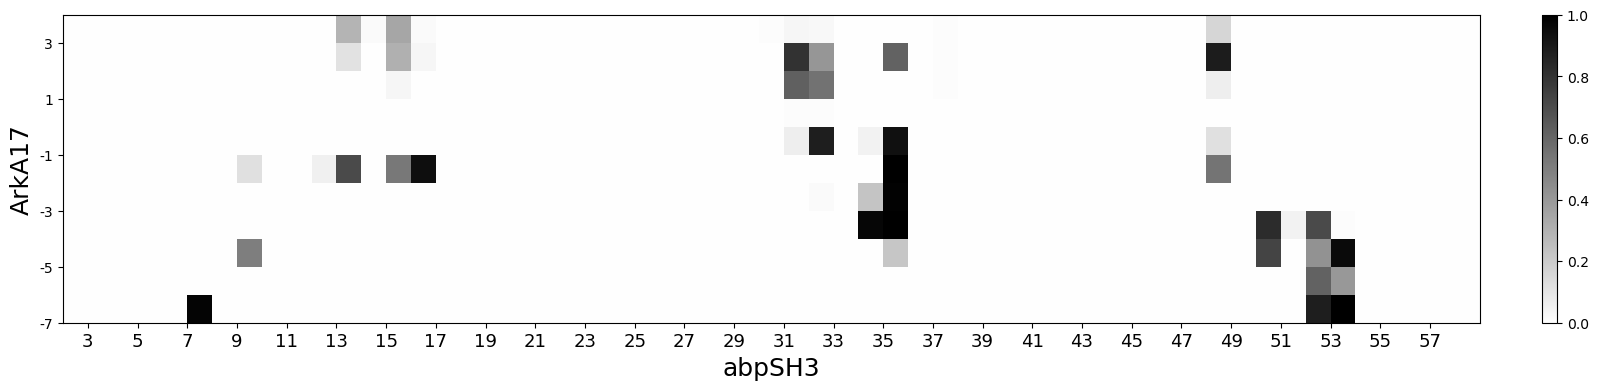

CPU times: user 512 ms, sys: 4.98 ms, total: 517 ms
Wall time: 519 ms


In [12]:
%%time
map = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","white","black"])

fig, ax = traj_no_salt_combined_contacts.residue_contacts.plot (nrows=1, ncols=1, figsize=(20, 4), cmap= map)

my_xticks = []
current_xticks = []

for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)

my_yticks =['-7','-5','-3','-1','1','3','5','7']
current_yticks = [60, 62, 64, 66, 68, 70, 72, 74]
ax.set_xticks 
ax.set_yticks 

#plt.xticks(np.array(current_xticks)+0.5, my_xticks, fontsize = 13) 
#plt.yticks(np.array(current_yticks)+0.5, my_yticks, fontsize = 13) 
#for y in range(int(minB), int(maxB)+1, 2):
    #current_yticks.append(y+0.5)
    #my_yticks.append(y)    
plt.xticks(current_xticks,my_xticks, fontsize = 13)
#plt.yticks(current_yticks, my_yticks, fontsize = 13)

ax.set_xticks 
ax.set_yticks 
ax.set_yticklabels(my_yticks)

ax.set_xlim(minA,maxA)
ax.set_ylim(minB,maxB-1)
plt.xlabel("abpSH3", fontsize=18)
plt.ylabel("ArkA17", fontsize=18)
plt.show()
#plt.title('ArkA12_bound_contact_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_phosphorylated.png', bbox_inches = "tight", dpi= 2000)

In [13]:
type(traj_no_salt_combined_contacts.residue_contacts)

contact_map.contact_count.ContactCount

# AbpSH3 ArkA12 Salt 

In [14]:
traj_list_salt = ["1_prod1-6_stripped.mdcrd", "2_prod1-6_stripped.mdcrd", "3_prod1-6_stripped.mdcrd", "4_prod1-6_stripped.mdcrd", "5_prod1-6_stripped.mdcrd", 
          "6_prod1-6_stripped.mdcrd", "7_prod1-6_stripped.mdcrd", "8_prod1-6_stripped.mdcrd", "9_prod1-6_stripped.mdcrd"]

traj_new_salt = []
for suffix in traj_list_salt:
    traj_new_salt.append(md.load_netcdf("/data/jcardoso/ArkA12_bound_salt/mdcrd/stripped_combined/" + suffix, 
                          top="//data/jcardoso/ArkA12_bound_salt/prmtop/abp1-arka12_800mM_NaCl_gas_ions.prmtop", stride=300 ))

In [15]:
topology = md.join(traj_new_salt).topology
df = topology.to_dataframe()[0]
topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])

/tmp/ipykernel_3592330/3525368574.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])


In [16]:
traj_combined_salt = md.join(traj_new_salt)

In [17]:
traj_combined_contacts_salt = ContactFrequency(traj_combined_salt)

In [18]:
def get_window(diffy):
    window = pd.DataFrame(diffy.residue_contacts.df.iloc[:maxB, :maxB]).fillna(0).iloc[minB-1:maxB-1, minA-1:maxA]
    return window.reindex(index=window.index[::-1])

In [19]:
diffy_salt = []
diffy_no_salt = []
for i in tqdm(range(min(len(traj_new_salt), len(traj_no_salt_new)))):
    #diffy.append(AtomMismatchedContactDifference(salt_con, no_salt_con))
    diffy_salt.append(ContactFrequency(traj_new_salt[i]))
    diffy_no_salt.append(ContactFrequency(traj_no_salt_new[i]))

  0%|          | 0/9 [00:00<?, ?it/s]

In [20]:
def ci_intersect(bs1, bs2):
    high1 = bs1.confidence_interval.high
    high2 = bs1.confidence_interval.high
    low1 = bs2.confidence_interval.low
    low2 = bs2.confidence_interval.low
    
    if low1 < low2:
        return high1 < low2
    else:
        return high2 < low1

In [21]:
def bootstrap(data1, data2, numsample=int(1e5)):
    _ = len(data1)
    len_2 = len(data2)
    
    data = np.concatenate([data1, data2])

    diff = abs(np.mean(data[:len_2]) - np.mean(data[len_2:]))
    
    diff_samples = np.zeros(numsample)
    diff_samples_larger = 0

    for sample in range(len(diff_samples)):
        random_groups = np.random.permutation(data)
        
        diff_samples[sample] = np.mean(random_groups[:len_2]) - np.mean(random_groups[len_2:])
        
        if diff_samples[sample] >= diff:
            diff_samples_larger += 1

    return (1 + diff_samples_larger) / (numsample + 1)

In [22]:
import scipy.stats

diff_df_salt = [get_window(diff) for diff in diffy_salt]
diff_df_no_salt = [get_window(diff) for diff in diffy_no_salt]
significant = diff_df_salt[0].copy().sparse.to_dense()

# p_val_df = diff_df_no_salt[0].copy(deep=True)
p_val_df = pd.DataFrame().reindex_like(diff_df_no_salt[0])

for col in tqdm(range(len(diff_df_salt[0].columns))):
    for row in range(len(diff_df_salt[0].index)):
        salt_data = [df.iloc[row, col] for df in diff_df_salt]
#         print(f"salty daty: ",row, col)
        no_salt_data = [df.iloc[row, col] for df in diff_df_no_salt]
        if all(v == 0 for v in no_salt_data) and all(v == 0 for v in salt_data):
            significant.iloc[row, col] = 1
        else:
            pval = bootstrap(salt_data, no_salt_data)
            significant.iloc[row, col] = pval
# p_val_df

  0%|          | 0/58 [00:00<?, ?it/s]

In [23]:
len(diff_df_salt[0].columns)

58

In [24]:
 print(significant.iloc[:15,8 ])  # Display all available rows of column ten since there are only 9 rows

70    1.000000
69    0.499875
68    1.000000
67    1.000000
66    1.000000
65    0.241168
64    1.000000
63    0.501995
62    0.011600
61    1.000000
60    1.000000
59    0.000500
Name: 8, dtype: float64


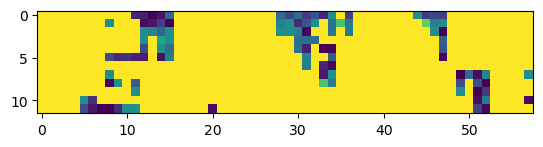

In [25]:
plt.imshow(np.array(significant.values.tolist()))

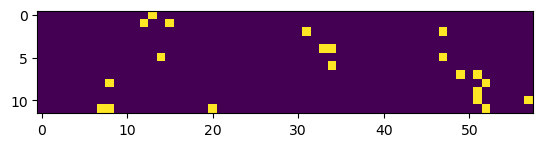

In [26]:
plt.imshow(np.array((significant < 0.05).values.tolist()))

In [27]:
np.where(significant < 0.05)

(array([ 0,  1,  1,  2,  2,  4,  4,  5,  5,  6,  7,  7,  8,  8,  9, 10, 10,
        11, 11, 11, 11]),
 array([13, 12, 15, 31, 47, 33, 34, 14, 47, 34, 49, 51,  8, 52, 51, 51, 57,
         7,  8, 20, 52]))

In [28]:
num_values = len(significant) * len(significant.columns) # following the Bonferroni Method
sig = np.array((significant < (0.05/num_values)).values.tolist())

In [29]:
np.where(sig)

(array([], dtype=int64), array([], dtype=int64))

In [30]:
p_val_df[(p_val_df < 0.05)]
#list(zip(list(np.argwhere(p_val_df.to_numpy())), list(np.where(p_val_df.to_numpy()))))

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
#bootstrap(traj)

In [32]:
dir(traj_combined_contacts_salt)
#traj_combined_contacts_salt.to_dict()

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__weakref__',
 '_all_atoms',
 '_all_residues',
 '_atom_contacts',
 '_build_contact_map',
 '_check_compatibility',
 '_class_use_atom_slice',
 '_contact_map',
 '_cutoff',
 '_deserialize_contact_counter',
 '_deserialize_topology',
 '_haystack',
 '_n_frames',
 '_n_neighbors_ignored',
 '_pending_dep_msg',
 '_query',
 '_residue_contacts',
 '_residue_ignore_atom_idxs',
 '_serialize_contact_counter',
 '_serialize_topology',
 '_set_atom_slice',
 '_topology',
 '_use_atom_slice',
 'add_contact_frequency',
 'all_atoms',
 'atom_contacts',
 'contacts',
 'cutoff',
 'from_contacts',
 'from_dict',
 'from_file',
 'from_json',

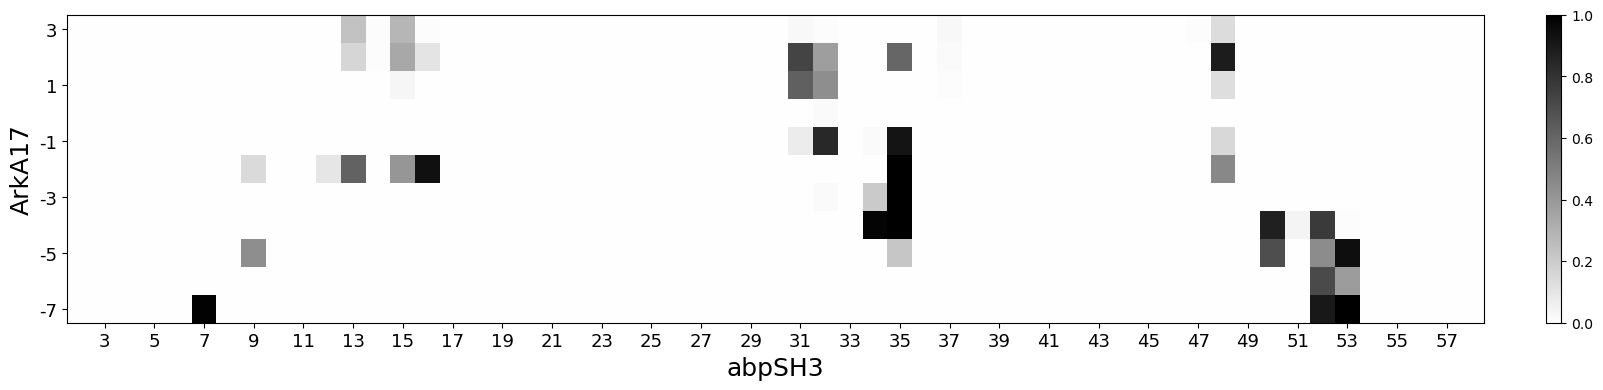

CPU times: user 10.9 s, sys: 71.9 ms, total: 10.9 s
Wall time: 11 s


In [33]:
%%time
fig, ax = traj_combined_contacts_salt.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap= map)

my_xticks = []
current_xticks = []

for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
my_yticks = ['-7','-5','-3','-1','1','3']
current_yticks = [60, 62, 64, 66, 68, 70]
#for y in range(int(minB), int(maxB)+1, 2):
   # current_yticks.append(y+0.5)
    #my_yticks.append(y)
plt.xticks(np.array(current_xticks)+0.5, my_xticks, fontsize = 13) 
plt.yticks(np.array(current_yticks)+0.5, my_yticks, fontsize = 13) 

#plt.xticks(current_xticks, my_xticks, fontsize = 13)
#plt.yticks(current_yticks, my_yticks, fontsize = 13)
ax.set_yticklabels(my_yticks, fontsize=13)
ax.set_xlim(minA,maxA)
ax.set_ylim(minB,maxB-1)
plt.xlabel("abpSH3", fontsize=18)
plt.ylabel("ArkA17", fontsize=18)

plt.show()
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_unphosphorylated.png', bbox_inches = "tight", dpi= 2000)


# ArkA12_Bound_Contact_Difference

In [34]:
diff = AtomMismatchedContactDifference(traj_no_salt_combined_contacts, traj_combined_contacts_salt)

In [35]:
traj_no_salt_combined_contacts.residue_contacts.df

,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,NaN,NaN,NaN,0.002361,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.002361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.729722,0.160556
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.002361,NaN,NaN,NaN,NaN,NaN,0.124583
69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000139,0.664028,0.92125,NaN,NaN,NaN,NaN,NaN
70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.006667,0.625694,0.597222,0.729722,NaN,NaN,NaN,NaN


In [36]:
traj_combined_contacts_salt.residue_contacts.df

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000972,0.001111,0.000972,0.001111,0.001389,0.000694,0.001667,0.001111,0.000278,0.000417
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000694,0.000278,0.000694,0.001111,0.000833,0.000556,0.001806,0.000694,0.000833,0.000972
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.001528,NaN,0.000139,0.000278,0.000694,0.000278,0.000139,0.000139,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002917,0.009583,0.003194,0.004028,0.005556,0.011111,0.003611,0.004306,0.004722,0.003611
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000833,0.001528,0.002222,0.001806,0.001806,0.001806,0.001806,0.001806,0.00125,0.00125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,0.000694,0.000556,0.000694,0.011111,0.001806,0.026806,0.006667,0.013611,0.001944,0.016806,...,0.003333,0.003056,0.001944,NaN,NaN,NaN,NaN,NaN,0.002222,0.002222
163,0.001667,0.001806,0.000278,0.003611,0.001806,0.028472,0.005972,0.011806,0.002083,0.017083,...,0.003056,0.003472,0.003194,0.004444,NaN,NaN,NaN,NaN,NaN,0.003333
164,0.001111,0.000694,0.000139,0.004306,0.001806,0.025694,0.005972,0.012639,0.001944,0.016389,...,0.002639,0.003056,0.002917,0.002639,0.002639,NaN,NaN,NaN,NaN,NaN
165,0.000278,0.000833,0.000139,0.004722,0.00125,0.024028,0.00625,0.024583,0.010139,0.030556,...,0.002917,0.002361,0.0025,0.001528,0.002778,0.002222,NaN,NaN,NaN,NaN


In [37]:
# current_xticks

[(3, 56), (3, 57), (9, 18), (14, 65), (18, 9), (18, 53), (22, 41), (31, 68), (32, 35), (35, 32), (41, 22), (53, 18), (56, 3), (57, 3), (65, 14), (68, 31)]


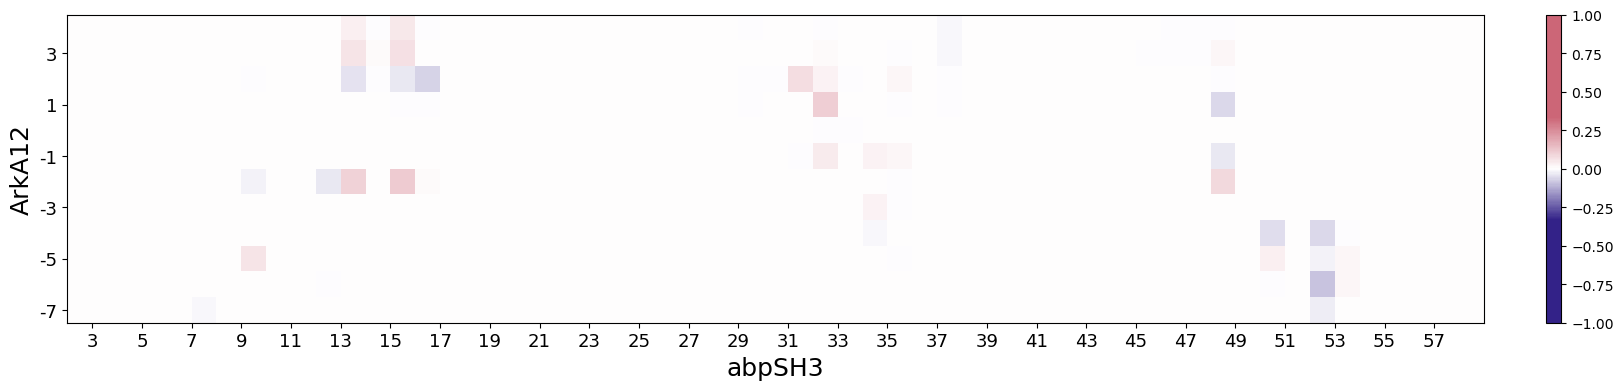

CPU times: user 1 s, sys: 13 ms, total: 1.01 s
Wall time: 1.02 s


In [38]:
%%time
map_1 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#332288","#332288","#332288","white","#CC6677","#CC6677","#CC6677"])
fig, ax = diff.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap = map_1) 
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []


for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
my_yticks = my_yticks = ['-7','-5','-3','-1','1','3']
plt.xticks(np.array(current_xticks)+0.5, my_xticks, fontsize = 13) 
plt.yticks(np.array(current_yticks)+0.5, my_yticks, fontsize = 13) 
current_yticks = [60, 62, 64, 66, 68, 70]
#for y in range(int(minB), int(maxB)+1, 2):
    #current_yticks.append(y+0.5)
    #my_yticks.append(y)
    
args = list(zip(*(np.abs(diff.residue_contacts.df.to_numpy()) > 0.1).nonzero()))
print(args)

#for x, y in args
    #plt.text(x + 0.5, y + 0.5, ':)', horizontalalignment='center', verticalalignment='center', size=12)
    
plt.xticks(current_xticks, my_xticks, fontsize = 13)
#plt.yticks(current_yticks, my_yticks, fontsize = 13)

ax.set_yticklabels(my_yticks)

ax.set_xlim(minA,maxA)
ax.set_ylim(minB,maxB)
plt.xlabel("abpSH3", fontsize=18)
plt.ylabel("ArkA12", fontsize=18)
#plt.title('ArkA12_bound_contact_difference_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_diff.png', bbox_inches = "tight", dpi= 2000)
plt.show()

In [39]:
significant

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
70,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
69,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,0.499875,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
68,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
67,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
66,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
65,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,0.241168,0.120169,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
64,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
63,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,0.501995,1.000000,...,1.0,0.000480,0.344557,0.033410,0.448936,1.0,1.0,1.0,1.0,0.499765
62,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,0.011600,0.500475,...,1.0,0.229088,1.000000,0.239248,0.001650,1.0,1.0,1.0,1.0,1.000000
61,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,0.499935,1.000000,0.006490,0.169318,1.0,1.0,1.0,1.0,1.000000


In [40]:
diff.residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]



,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
59,NaN,NaN,NaN,NaN,NaN,0.002778,0.012222,0.05125,0.075833,-0.029861,...,NaN,NaN,NaN,0.007917,0.023194,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN,NaN,0.000139,-0.010833,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.025833,0.000278,NaN,NaN,NaN,NaN,0.005833
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.000139,NaN,-0.093194,0.018611,NaN,NaN,NaN,NaN,NaN
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.061389,0.000139,...,NaN,0.037778,NaN,-0.019444,0.016806,NaN,NaN,NaN,NaN,NaN
63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000139,NaN,...,NaN,-0.053472,0.0025,-0.05875,-0.000833,NaN,NaN,NaN,NaN,0.001528
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.020833,0.000556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


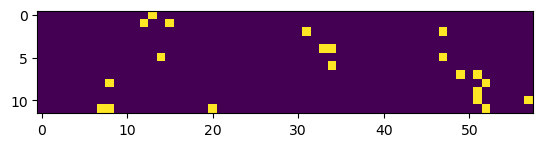

In [41]:
plt.imshow(np.array((significant < 0.05).values.tolist()))

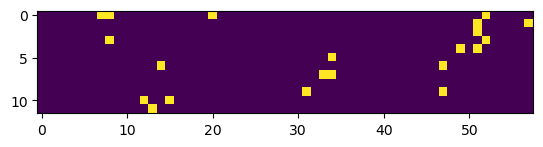

In [42]:
# Flip rows of significant dataframe to match with correct rows of diff dataframe
significant_rev = significant.iloc[::-1]
plt.imshow(np.array((significant_rev < 0.05).values.tolist()))

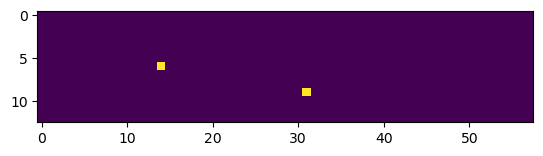

In [43]:
plt.imshow(np.array((diff.residue_contacts.df.iloc[minB-1:maxB, minA-1:maxA] > 0.1).values.tolist()))

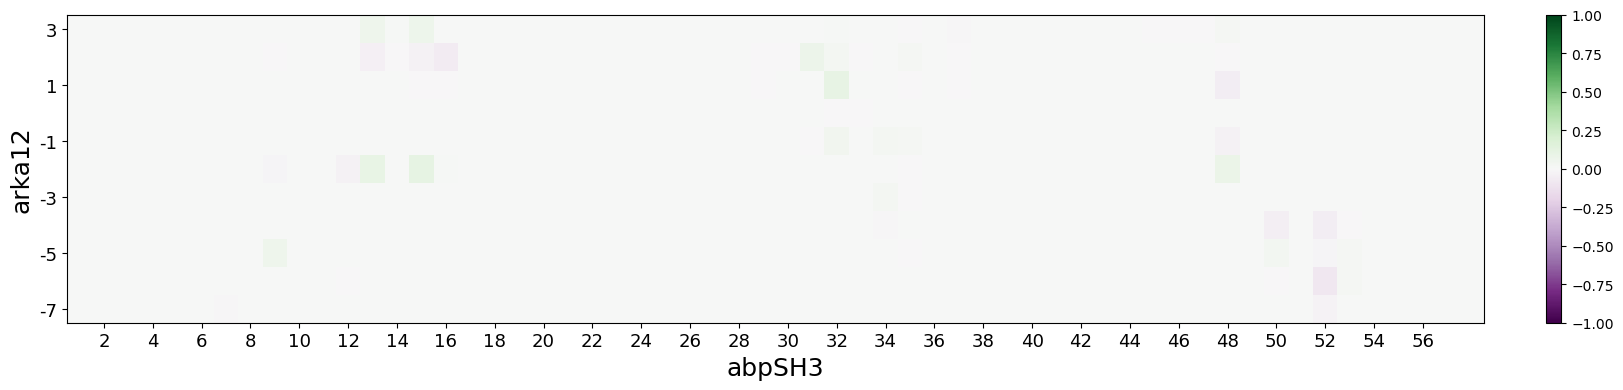

CPU times: user 532 ms, sys: 4.99 ms, total: 537 ms
Wall time: 538 ms


In [44]:
%%time
fig, ax = diff.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap = "PRGn") 
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []

for x in range(int(minA)-1, int(maxA), 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
my_yticks = my_yticks = ['-7','-5','-3','-1','1','3']
current_yticks = [60, 62, 64, 66, 68, 70]
#for y in range(int(minB), int(maxB)+1, 2):
    #current_yticks.append(y+0.5)
    #my_yticks.append(y)
    
plt.xticks(current_xticks, my_xticks, fontsize = 13)
#plt.yticks(current_yticks, my_yticks, fontsize = 13)
plt.xticks(np.array(current_xticks)+0.5, my_xticks, fontsize = 13) 
plt.yticks(np.array(current_yticks)+0.5, my_yticks, fontsize = 13) 

ax.set_yticklabels(my_yticks)

ax.set_xlim(0,58)
ax.set_ylim(60,71)
plt.xlabel("abpSH3", fontsize=18)
plt.ylabel("arka12", fontsize=18)
#plt.title('ArkA12_bound_contact_difference_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_diff.png', bbox_inches = "tight", dpi= 2000)
plt.show()

In [45]:

contact_diff_data = diff.residue_contacts.df

#Display the DataFrame
#print(sorted(list(set(list(contact_diff_df['Residue_B'])))))
#dir(contact_diff_data)
#contact_diff_data
#fig, ax = diff.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap = "PRGn") 
window = (contact_diff_data.iloc[:72, :72]).fillna(0).iloc[60:72, 0:58]
window = window.reindex(index=window.index[::-1])

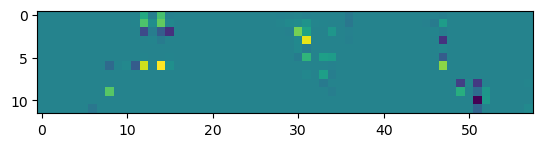

In [46]:

plt.imshow(window)


In [47]:
window

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
70,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69,0,0,0,0,0,0,0,0,-0.000278,0,...,0,0,0,0,0,0,0,0,0,0
68,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
67,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
66,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
65,0,0,0,0,0,0,0,0,-0.020833,0.000556,...,0,0,0,0,0,0,0,0,0,0
64,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
63,0,0,0,0,0,0,0,0,0.000139,0,...,0,-0.053472,0.0025,-0.05875,-0.000833,0,0,0,0,0.001528
62,0,0,0,0,0,0,0,0,0.061389,0.000139,...,0,0.037778,0,-0.019444,0.016806,0,0,0,0,0


In [48]:
# Inspect the attributes and methods of the diff.residue_contacts object
print(dir(diff.residue_contacts))


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_check_number_of_pixels', '_counter', '_object_f', 'counter', 'df', 'filter', 'most_common', 'most_common_idx', 'n_x', 'n_y', 'plot', 'plot_axes', 'sparse_matrix']


In [49]:
# understanding the attributes of the ContactFrequency objects
print(dir(traj_no_salt_combined_contacts))
print(dir(traj_combined_contacts_salt))


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__weakref__', '_all_atoms', '_all_residues', '_atom_contacts', '_build_contact_map', '_check_compatibility', '_class_use_atom_slice', '_contact_map', '_cutoff', '_deserialize_contact_counter', '_deserialize_topology', '_haystack', '_n_frames', '_n_neighbors_ignored', '_pending_dep_msg', '_query', '_residue_contacts', '_residue_ignore_atom_idxs', '_serialize_contact_counter', '_serialize_topology', '_set_atom_slice', '_topology', '_use_atom_slice', 'add_contact_frequency', 'all_atoms', 'atom_contacts', 'contacts', 'cutoff', 'from_contacts', 'from_dict', 'from_file', 'from_json', 'haystack', 'haystack_residue_range', 'haystack_residues'

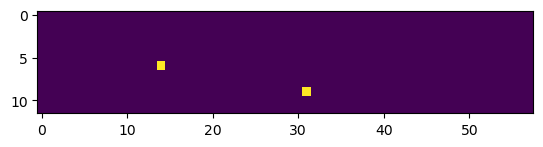

In [54]:

#np.array((significant[significant < 0.05]).values.tolist())
#ax.set_ylim(60, 71)
#ax.set_xlim(0,58)
salt = traj_combined_contacts_salt.residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]
no_salt = traj_no_salt_combined_contacts.residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]
difference = diff.residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]

perc_diff = ((difference.abs())/((salt + no_salt)/2))*100
plt.imshow(np.array((difference.abs() > 0.1).values.tolist()))


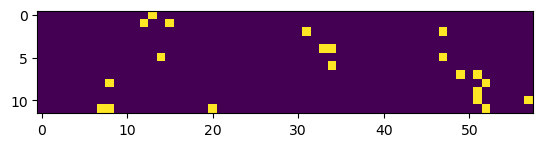

In [55]:
plt.imshow(np.array((significant < 0.05).values.tolist()))

In [56]:
significant

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
70,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
69,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,0.499875,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
68,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
67,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
66,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
65,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,0.241168,0.120169,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
64,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.000000
63,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,0.501995,1.000000,...,1.0,0.000480,0.344557,0.033410,0.448936,1.0,1.0,1.0,1.0,0.499765
62,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,0.011600,0.500475,...,1.0,0.229088,1.000000,0.239248,0.001650,1.0,1.0,1.0,1.0,1.000000
61,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.0,0.499935,1.000000,0.006490,0.169318,1.0,1.0,1.0,1.0,1.000000


Current dimensions: 6.4 x 4.8 inches
New dimensions: 7 x 5.249999999999999 inches


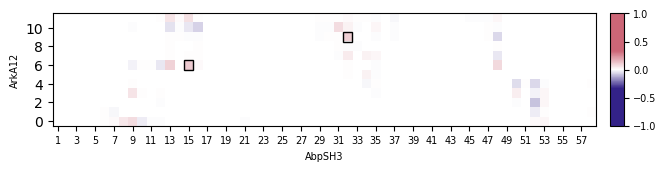

In [58]:
num_values = len(significant_rev) * len(significant_rev.columns) # following the Bonferroni Method
#sig_and_10 = np.array((significant < (0.05/num_values)).values.tolist()) & np.array((abs(difference) > 0.1).values.tolist())
#sig_and_10 = np.array((significant < (0.05/num_values)).values.tolist())
sig_and_10 = np.array((significant_rev < (0.05)).values.tolist()) & np.array((abs(difference) > 0.1).values.tolist())
coords = np.argwhere(sig_and_10)

map_1 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#332288","#332288","#332288","white","#CC6677","#CC6677","#CC6677"])
#fig, ax = difference.residue_contacts.plot(cmap = map_1)

fig, ax = plt.subplots()
im = plt.imshow(difference, cmap = map_1, vmin = -1, vmax = 1)
# 1. Get the current position of the plot in the figure
pos = ax.get_position()

# --- MISSING PIECE START ---
# Define the colorbar axes [left, bottom, width, height]
# pos.x1 + 0.02 puts it just to the right of the plot
# pos.y0 and pos.height ensure the vertical size matches exactly
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
# --- MISSING PIECE END ---

# Now this will work
cb = fig.colorbar(im, cax=cax)
cax.tick_params(labelsize=7)

# 2. Extract coordinates where mask is True
# Note: np.argwhere returns (row, col), but patches use (x, y) which is (col, row)

for row, col in coords:
    # Create a Rectangle patch
    # (col - 0.5, row - 0.5) aligns the box edges with the pixel edges
    rect = patches.Rectangle((col - 0.5, row - 0.5), 1, 1, 
                             linewidth=1, edgecolor='black', facecolor='none')
    ax.add_patch(rect)

#cb_ax = fig.axes[0]
#cb_ax.tick_params(labelsize=7)
#plt.imshow(np.array((significant < 0.05).values.tolist()))
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []


for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
# --- Y-Axis Relabeling ---
#my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
#my_yticks = ['7','5','3', '1', '-1', '-3', '-5', '-7', '-9','-11'] # ArkA17 goes from K(6) to K(-10)
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
#current_yticks = np.linspace(0, 17, len(my_yticks))
my_yticks = ['6', '4', '2', '0', '-2', '-4', '-6', '-8', '-10'] # correct labelling
current_yticks = np.arange(0, 12, 2)

ax.set_xlabel("AbpSH3", fontsize = 7)
ax.set_ylabel("ArkA12", fontsize = 7)

my_xticks = []
current_xticks = []

# Loop through every single number in the range
for x in range(int(minA)-1, int(maxA)):
    # Check if the residue number is odd
    if x % 2 != 0:
        current_xticks.append(x - int(minA)) # The pixel position
        my_xticks.append(x)                  # The actual label

# Apply to the plot
ax.set_xticks(current_xticks)
ax.set_xticklabels(my_xticks, fontsize=7)
ax.set_yticks(current_yticks)
#ax.set_yticklabels(my_yticks, fontsize=7)
ax.invert_yaxis()
#ax.set_ylim(60, 71)
#ax.set_xlim(0,58)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('ArkA12_bound_contact_diff.png', dpi=1000, bbox_inches='tight')

plt.show()

In [59]:
difference

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
59,NaN,NaN,NaN,NaN,NaN,0.002778,0.012222,0.05125,0.075833,-0.029861,...,NaN,NaN,NaN,0.007917,0.023194,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,NaN,NaN,0.000139,-0.010833,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.025833,0.000278,NaN,NaN,NaN,NaN,0.005833
61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.000139,NaN,-0.093194,0.018611,NaN,NaN,NaN,NaN,NaN
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.061389,0.000139,...,NaN,0.037778,NaN,-0.019444,0.016806,NaN,NaN,NaN,NaN,NaN
63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000139,NaN,...,NaN,-0.053472,0.0025,-0.05875,-0.000833,NaN,NaN,NaN,NaN,0.001528
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.020833,0.000556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
avg_salt_contacts_list = []
for traj in range(len(traj_new_salt)):
    ind_df = ContactFrequency(traj_new_salt[traj]).residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]
    avg_salt_contacts = ind_df.sum().sum()
    avg_salt_contacts_list.append(avg_salt_contacts)

avg_no_salt_contacts_list = []
for traj in range(len(traj_no_salt_new)):
    ind_df = ContactFrequency(traj_no_salt_new[traj]).residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]
    avg_no_salt_contacts = ind_df.sum().sum()
    avg_no_salt_contacts_list.append(avg_no_salt_contacts)

# Combine avg contact data (TOTAL)
avg_contact_values = np.concatenate([avg_no_salt_contacts_list, avg_salt_contacts_list])

nsim = 10

#calculate the real difference, no salt minus salt
diff_total = np.array(avg_no_salt_contacts_list).mean() - np.array(avg_salt_contacts_list).mean()

print("Avg # total contacts no-salt minus salt difference = " , diff_total)

#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    random_groups = np.random.permutation(avg_contact_values)
    diff_samples[sample] = (np.mean(random_groups[0:nsim]) 
             - np.mean(random_groups[nsim:nsim + nsim]))
    if diff_samples[sample] >= diff_total:
        diff_samples_larger[sample] = 1

#calculate p-value
pval_diff = (1 + np.sum(diff_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff)

Avg # total contacts no-salt minus salt difference =  0.5123611111111082
p-value =  0.14778522147785222


In [71]:
np.array(avg_no_salt_contacts_list).mean()

26.110833333333332

In [72]:
st.sem(np.array(avg_no_salt_contacts_list))

0.3088504250757062

In [73]:
np.array(avg_salt_contacts_list).mean()

25.598472222222224

In [74]:
st.sem(np.array(avg_salt_contacts_list))

0.3577465992065152